In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import time
from sklearn.pipeline import Pipeline

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

In [3]:
# Load a classification dataset
cancer = load_breast_cancer()
X_class = cancer.data
y_class = cancer.target

In [4]:
# Load a regression dataset
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

In [5]:
# Split data into training and testing sets
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [6]:
# Standardize features
scaler = StandardScaler()
X_class_train_scaled = scaler.fit_transform(X_class_train)
X_class_test_scaled = scaler.transform(X_class_test)

In [7]:
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# Part 1: Grid Search for SVM Classifier

In [8]:
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

In [9]:
# Create SVM classifier
svm = SVC(random_state=42)

In [10]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy',
    return_train_score=True
)

In [11]:
# Start timing
start_time = time.time()


In [12]:
# Fit GridSearchCV
grid_search.fit(X_class_train_scaled, y_class_train)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [0.001, 0.01, ...], 'kernel': ['rbf', 'poly']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,100


In [13]:
# End timing
grid_time = time.time() - start_time

In [14]:
# Print results
print(f"Grid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Grid Search completed in 20.99 seconds
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9736


In [15]:
# Evaluate on test set
y_pred = grid_search.predict(X_class_test_scaled)
grid_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {grid_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9825


In [16]:
# Visualization of Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

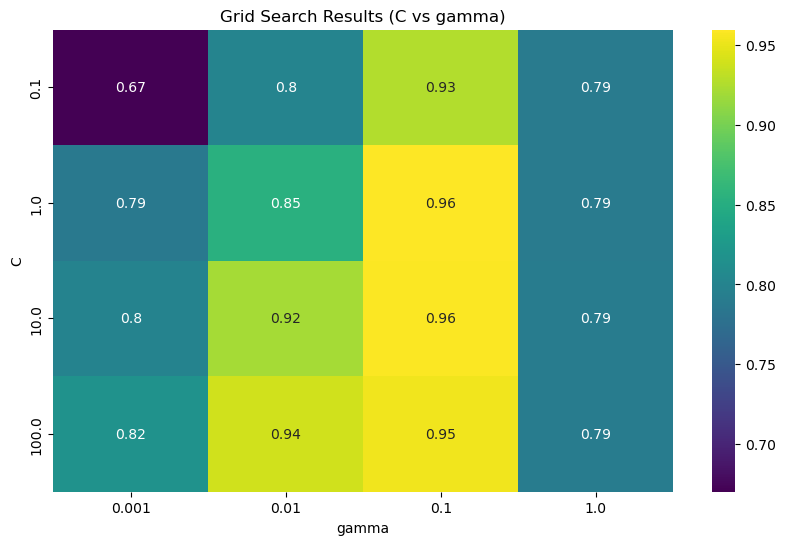

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(grid_pivot, annot=True, cmap='viridis')
plt.title('Grid Search Results (C vs gamma)')
plt.ylabel('C')
plt.xlabel('gamma')
plt.show()


# Part 2: Random Search for SVM Classifier

In [18]:
# Define the parameter distributions
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'poly']
}


In [19]:
# Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [20]:
# Start timing
start_time = time.time()

In [21]:
# Fit RandomizedSearchCV
random_search.fit(X_class_train_scaled, y_class_train)

,estimator,SVC(random_state=42)
,param_distributions,"{'C': <scipy.stats....001D3ACDCE7D0>, 'gamma': <scipy.stats....001D3AD0B56C0>, 'kernel': ['rbf', 'poly']}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [22]:
# End timing
random_time = time.time() - start_time

In [23]:
# Print results
print(f"Random Search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

Random Search completed in 4.64 seconds
Best parameters: {'C': np.float64(0.8066305219717406), 'gamma': np.float64(0.024062425041415758), 'kernel': 'rbf'}
Best cross-validation score: 0.9714


In [24]:
# Evaluate on test set
y_pred = random_search.predict(X_class_test_scaled)
random_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {random_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9649


In [25]:
# Compare Grid Search and Random Search
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy],
    'Execution Time (s)': [grid_time, random_time]
})

print("\nComparison of Grid Search and Random Search:")
print(results_comparison)


Comparison of Grid Search and Random Search:
          Method  Best CV Score  Test Accuracy  Execution Time (s)
0    Grid Search       0.973626       0.982456           20.985631
1  Random Search       0.971429       0.964912            4.638660


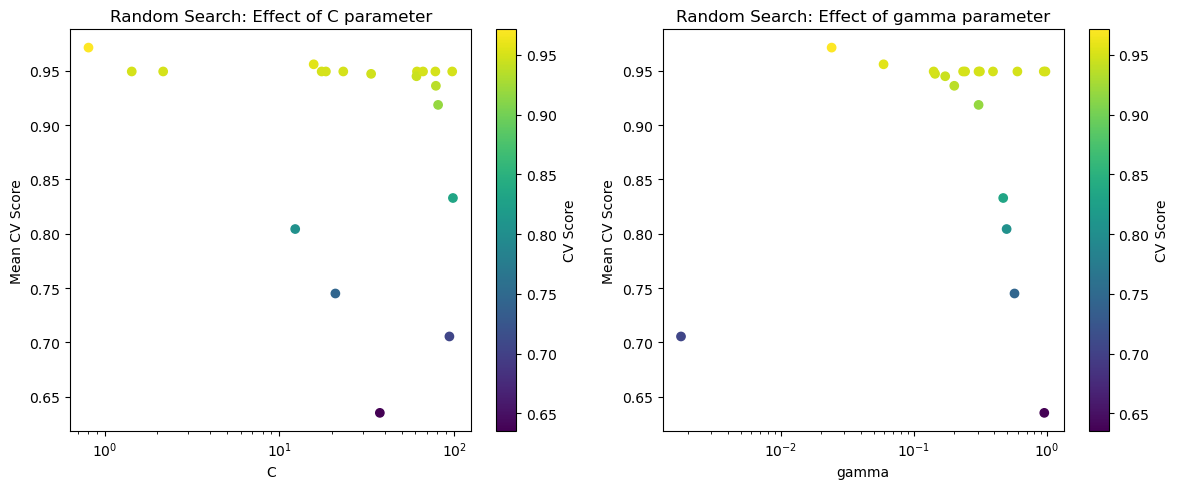

In [26]:
# Visualize random search results - plot parameter samples and their scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(random_search.cv_results_['param_C'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of C parameter')

plt.subplot(1, 2, 2)
plt.scatter(random_search.cv_results_['param_gamma'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of gamma parameter')
plt.tight_layout()
plt.show()

# Part 3: Bayesian Optimization using scikit-optimize (skopt)

In [27]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

In [28]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [29]:
# Define the search space
search_spaces = {
    'C': Real(0.1, 100, prior='log-uniform'),
    'gamma': Real(0.001, 1.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'poly'])
}

In [30]:
# Create BayesSearchCV object
bayes_search = BayesSearchCV(
    estimator=svm,
    search_spaces=search_spaces,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [31]:
# Start timing
start_time = time.time()

In [32]:
# Fit BayesSearchCV
bayes_search.fit(X_class_train_scaled, y_class_train)

,estimator,SVC(random_state=42)
,search_spaces,"{'C': Real(low=0.1,...m='normalize'), 'gamma': Real(low=0.00...m='normalize'), 'kernel': Categorical(c...), prior=None)}"
,optimizer_kwargs,None
,n_iter,20
,scoring,'accuracy'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [33]:
# End timing
bayes_time = time.time() - start_time

In [34]:
# Print results
print(f"Bayesian Optimization completed in {bayes_time:.2f} seconds")
print(f"Best parameters: {bayes_search.best_params_}")
print(f"Best cross-validation score: {bayes_search.best_score_:.4f}")

Bayesian Optimization completed in 31.10 seconds
Best parameters: OrderedDict([('C', 47.479208101335), ('gamma', 0.01504196944418048), ('kernel', 'rbf')])
Best cross-validation score: 0.9626


In [35]:
# Evaluate on test set
y_pred = bayes_search.predict(X_class_test_scaled)
bayes_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {bayes_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9561


In [36]:
# Update comparison table
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_, bayes_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy, bayes_accuracy],
    'Execution Time (s)': [grid_time, random_time, bayes_time]
})

print("\nComparison of all methods:")
print(results_comparison)


Comparison of all methods:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456           20.985631
1          Random Search       0.971429       0.964912            4.638660
2  Bayesian Optimization       0.962637       0.956140           31.102604


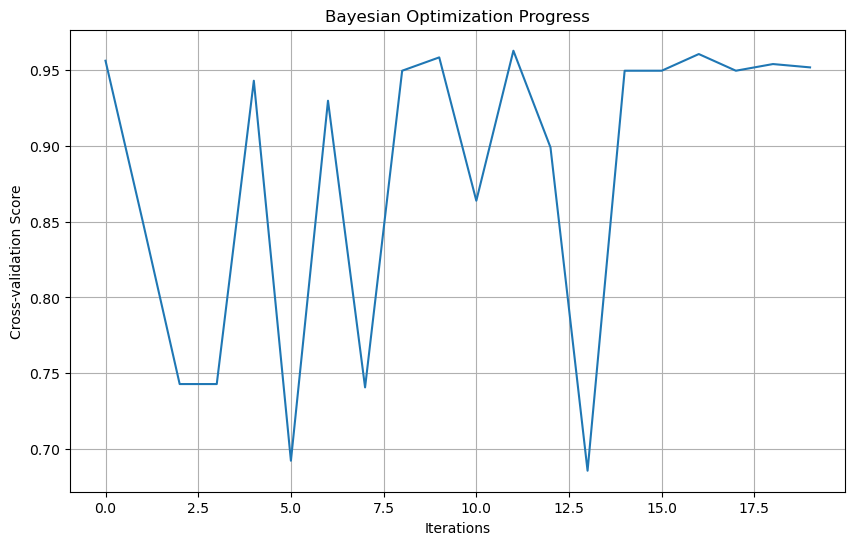

In [37]:
# Visualize Bayesian Optimization progress
plt.figure(figsize=(10, 6))
plt.plot(bayes_search.cv_results_['mean_test_score'])
plt.xlabel('Iterations')
plt.ylabel('Cross-validation Score')
plt.title('Bayesian Optimization Progress')
plt.grid(True)
plt.show()

# Part 4: Random Forest Regression with hyperparameter tuning

In [38]:
# Create a pipeline for regression
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [39]:
# Define parameter distributions for random search
rf_param_dist = {
    'regressor__n_estimators': randint(10, 200),
    'regressor__max_depth': randint(3, 20),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['auto', 'sqrt', 'log2', None]
}

In [40]:
# Create RandomizedSearchCV for regression
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

In [42]:
# Start timing
start_time = time.time()

In [43]:
# Fit RandomizedSearchCV
rf_random_search.fit(X_reg_train, y_reg_train)

c:\Users\IT LAND\miniconda3\envs\ai-bootcamp\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\IT LAND\miniconda3\envs\ai-bootcamp\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\IT LAND\miniconda3\envs\ai-bootcamp\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\IT LAND\miniconda3\envs\ai-bootcamp\lib\site-packages\sklearn\pipeline.py", line 663, in fi

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'regressor__max_depth': <scipy.stats....001D3AD933A60>, 'regressor__max_features': ['auto', 'sqrt', ...], 'regressor__min_samples_leaf': <scipy.stats....001D3ADDAEA70>, 'regressor__min_samples_split': <scipy.stats....001D3ADDACA60>, ...}"
,n_iter,20
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [44]:
# End timing
rf_random_time = time.time() - start_time

In [45]:
# Print results
print("\nRandom Forest Regression Hyperparameter Tuning Results:")
print(f"Random Search completed in {rf_random_time:.2f} seconds")
print(f"Best parameters: {rf_random_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {rf_random_search.best_score_:.4f}")


Random Forest Regression Hyperparameter Tuning Results:
Random Search completed in 14.61 seconds
Best parameters: {'regressor__max_depth': 18, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 15, 'regressor__n_estimators': 199}
Best cross-validation score (neg_mean_squared_error): -3316.3419


In [46]:
# Evaluate on test set
y_pred = rf_random_search.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_pred)
r2 = r2_score(y_reg_test, y_pred)
print(f"Test MSE with optimal parameters: {mse:.4f}")
print(f"Test R² with optimal parameters: {r2:.4f}")

Test MSE with optimal parameters: 2808.9704
Test R² with optimal parameters: 0.4698


In [47]:
# Visualize feature importance from the best model
best_rf = rf_random_search.best_estimator_.named_steps['regressor']
feature_importance = best_rf.feature_importances_
feature_names = diabetes.feature_names

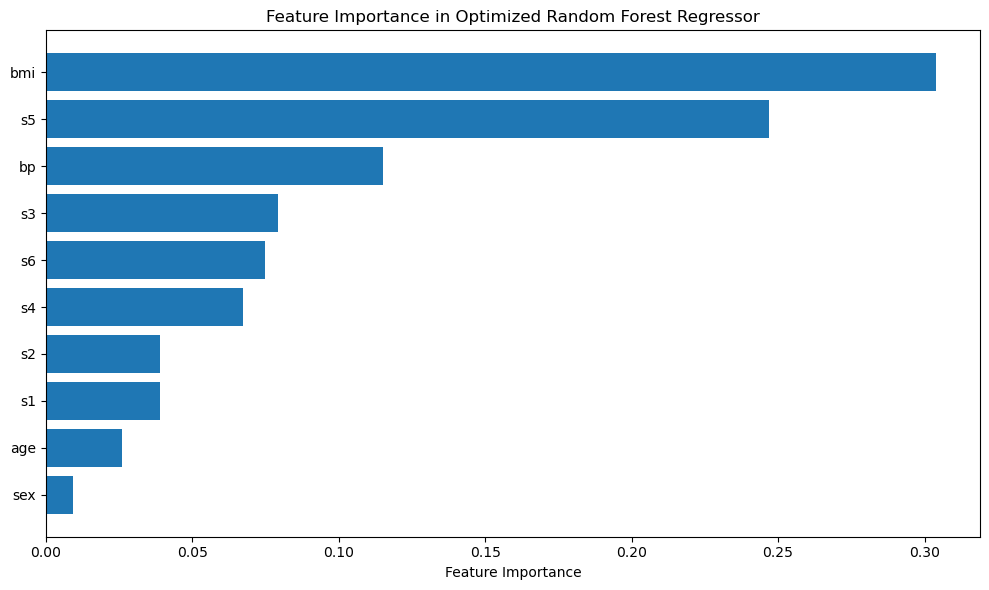

In [48]:
# Sort feature importances
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Optimized Random Forest Regressor')
plt.tight_layout()
plt.show()

# Part 5: Learning Curves for different hyperparameter settings

In [49]:
def plot_learning_curve(estimator, X, y, title, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [50]:
from sklearn.model_selection import learning_curve


In [51]:
# Plot learning curves for SVM with different hyperparameters
plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

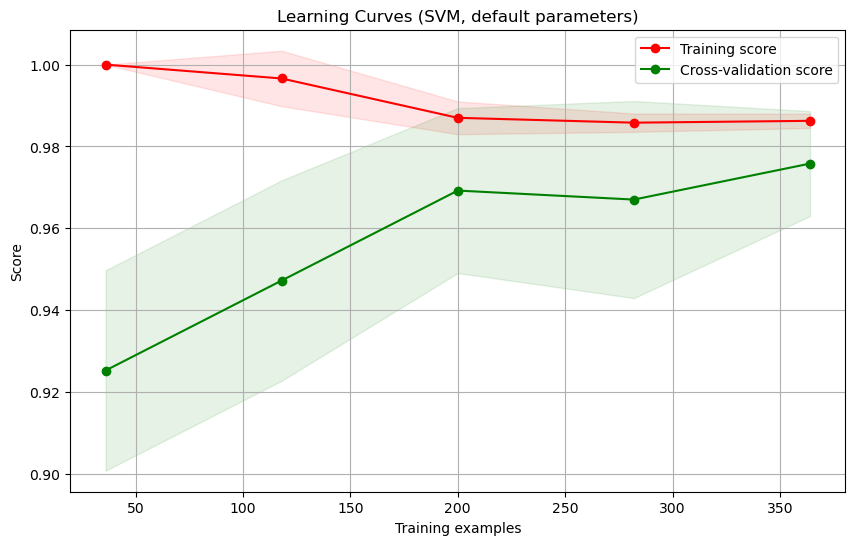

In [52]:
# Default parameters
svm_default = SVC(random_state=42)
plot_learning_curve(svm_default, X_class_train_scaled, y_class_train,
                   "Learning Curves (SVM, default parameters)")
plt.savefig('svm_default_learning_curve.png')

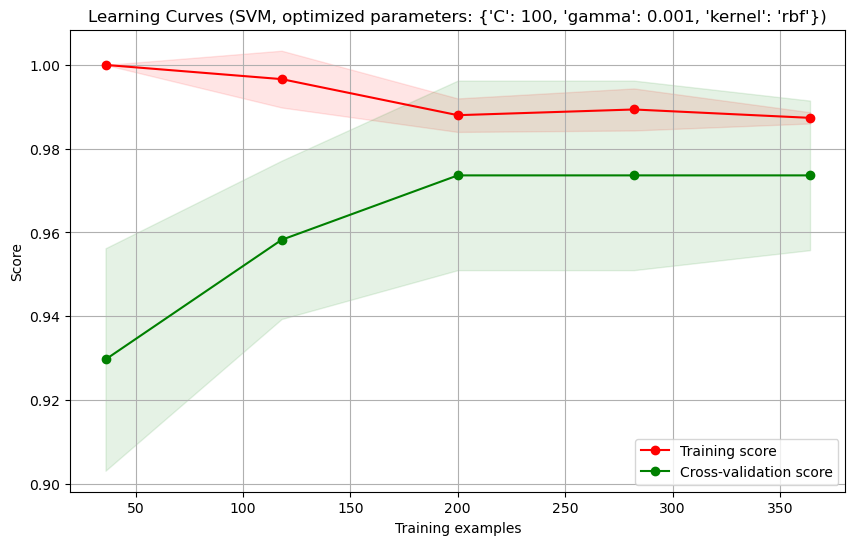

In [53]:
# Best parameters from grid search
svm_best = SVC(**grid_search.best_params_, random_state=42)
plot_learning_curve(svm_best, X_class_train_scaled, y_class_train,
                   f"Learning Curves (SVM, optimized parameters: {grid_search.best_params_})")
plt.savefig('svm_optimized_learning_curve.png')

# Part 6: Cross-validation visualization for different hyperparameters

In [54]:
# Function to run cross-validation with different hyperparameters and visualize results
def plot_cv_results(param_name, param_range, estimator, X, y, cv=5, scoring='accuracy'):
    cv_scores = []
    for param_value in param_range:
        params = {param_name: param_value}
        estimator.set_params(**params)
        scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring)
        cv_scores.append((param_value, np.mean(scores), np.std(scores)))

    cv_df = pd.DataFrame(cv_scores, columns=[param_name, 'Mean Score', 'Std Dev'])

    plt.figure(figsize=(10, 6))
    plt.errorbar(cv_df[param_name], cv_df['Mean Score'], yerr=cv_df['Std Dev'], marker='o')
    plt.title(f'Cross-validation scores for different {param_name} values')
    plt.xlabel(param_name)
    plt.ylabel('Mean CV Score')
    plt.grid(True)
    if param_name in ['C', 'gamma']:
        plt.xscale('log')
    return cv_df

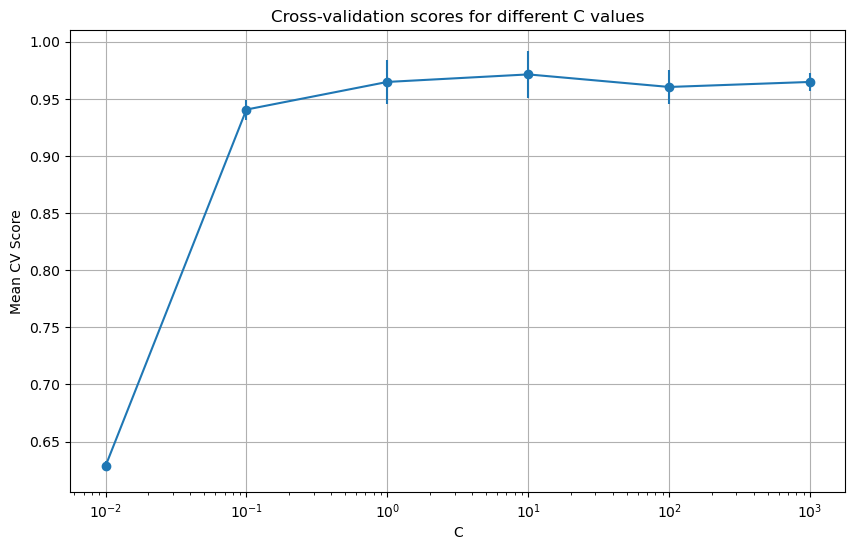

In [55]:
# Run CV visualization for C parameter
svm_model = SVC(kernel='rbf', gamma=0.01, random_state=42)
C_range = [0.01, 0.1, 1, 10, 100, 1000]
cv_results_C = plot_cv_results('C', C_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

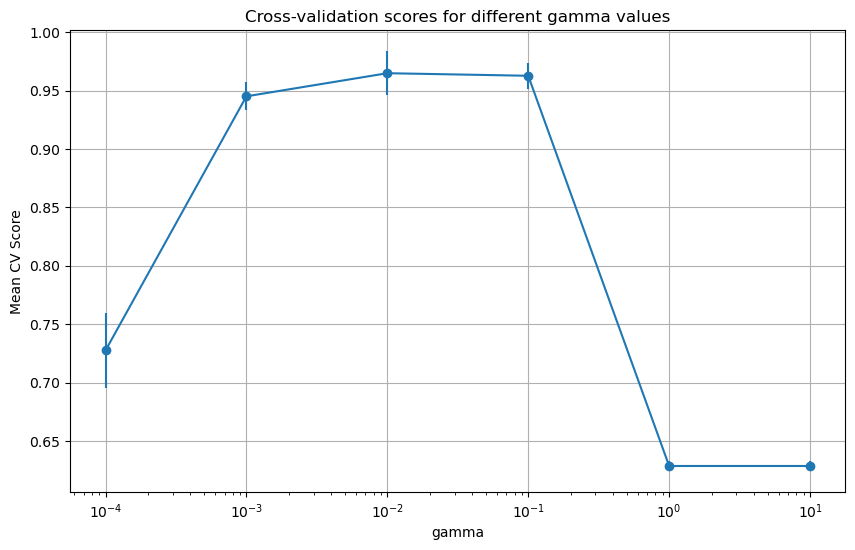

In [56]:
# Run CV visualization for gamma parameter
svm_model = SVC(kernel='rbf', C=1, random_state=42)
gamma_range = [0.0001, 0.001, 0.01, 0.1, 1, 10]
cv_results_gamma = plot_cv_results('gamma', gamma_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

# Part 7: Combining Grid Search and Random Search strategies

In [57]:
# Define a smaller search space for initial grid search
coarse_param_grid = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

In [58]:
# Create GridSearchCV object for coarse search
coarse_grid_search = GridSearchCV(
    estimator=svm,
    param_grid=coarse_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy'
)


In [59]:
# Perform coarse grid search
coarse_grid_search.fit(X_class_train_scaled, y_class_train)
best_C = coarse_grid_search.best_params_['C']
best_gamma = coarse_grid_search.best_params_['gamma']
best_kernel = coarse_grid_search.best_params_['kernel']

print(f"Coarse grid search best parameters: C={best_C}, gamma={best_gamma}, kernel={best_kernel}")


Coarse grid search best parameters: C=10, gamma=0.001, kernel=rbf


In [60]:
# Define refined search space around the best parameters
if best_kernel == 'rbf':
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['rbf']
    }
else:
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5]
    }

In [61]:
# Create RandomizedSearchCV object for refined search
refined_random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=refined_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy'
)

In [62]:
# Perform refined random search
refined_random_search.fit(X_class_train_scaled, y_class_train)

,estimator,SVC(random_state=42)
,param_distributions,"{'C': <scipy.stats....001D3AD0592A0>, 'gamma': <scipy.stats....001D3AD00EDA0>, 'kernel': ['rbf']}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [63]:
print(f"Refined random search best parameters: {refined_random_search.best_params_}")
print(f"Refined random search best score: {refined_random_search.best_score_:.4f}")

Refined random search best parameters: {'C': np.float64(21.55967889037648), 'gamma': np.float64(0.0008449057043952079), 'kernel': 'rbf'}
Refined random search best score: 0.9780


In [64]:
# Evaluate on test set
y_pred = refined_random_search.predict(X_class_test_scaled)
refined_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {refined_accuracy:.4f}")


Test accuracy with optimal parameters: 0.9825


In [65]:
# Update comparison table
results_comparison['Method'] = pd.Categorical(
    results_comparison['Method'],
    categories=['Grid Search', 'Random Search', 'Bayesian Optimization', 'Combined Approach'],
    ordered=True
)


In [66]:
combined_approach = pd.DataFrame({
    'Method': ['Combined Approach'],
    'Best CV Score': [refined_random_search.best_score_],
    'Test Accuracy': [refined_accuracy],
    'Execution Time (s)': [None]  # We didn't time this approach
})

In [67]:
results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)
print("\nComparison of all methods including combined approach:")
print(results_comparison)


Comparison of all methods including combined approach:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456           20.985631
1          Random Search       0.971429       0.964912            4.638660
2  Bayesian Optimization       0.962637       0.956140           31.102604
3      Combined Approach       0.978022       0.982456                 NaN


C:\Users\IT LAND\AppData\Local\Temp\ipykernel_8840\3157594516.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)


# Part 8: Visualizing hyperparameter importance

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [69]:
# Train a model with the best parameters from Bayesian search
best_svm = SVC(**bayes_search.best_params_, random_state=42, probability=True)
best_svm.fit(X_class_train_scaled, y_class_train)

,C,47.479208101335
,kernel,'rbf'
,degree,3
,gamma,0.01504196944418048
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [70]:
# Create a dataset of different hyperparameter configurations and their performance
hyperparam_data = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    score = grid_search.cv_results_['mean_test_score'][i]

    # Encode the kernel
    kernel_rbf = 1 if params['kernel'] == 'rbf' else 0
    kernel_poly = 1 if params['kernel'] == 'poly' else 0

    hyperparam_data.append([params['C'], params['gamma'], kernel_rbf, kernel_poly, score])

hyperparam_df = pd.DataFrame(hyperparam_data,
                             columns=['C', 'gamma', 'kernel_rbf', 'kernel_poly', 'score'])

In [71]:
# Train a random forest to predict model performance based on hyperparameters
X_hyperparam = hyperparam_df.iloc[:, :-1].values
y_hyperparam = hyperparam_df.iloc[:, -1].values

rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_hyperparam, y_hyperparam)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
# Get feature importances
importances = rf_importance.feature_importances_
feature_names = ['C', 'gamma', 'kernel_rbf', 'kernel_poly']

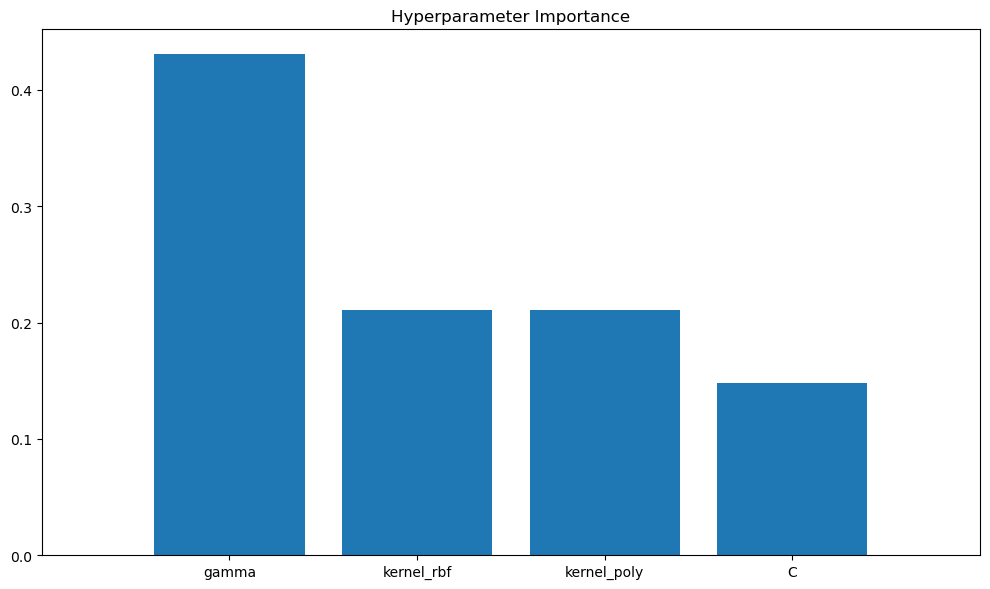

In [74]:
# Plot feature importances
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.title('Hyperparameter Importance')
plt.bar(range(X_hyperparam.shape[1]), importances[indices], align='center')
plt.xticks(range(X_hyperparam.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X_hyperparam.shape[1]])
plt.tight_layout()
plt.show()

In [75]:
# Calculate permutation importances as an alternative measure
perm_importance = permutation_importance(rf_importance, X_hyperparam, y_hyperparam,
                                         n_repeats=10, random_state=42)

C:\Users\IT LAND\AppData\Local\Temp\ipykernel_8840\149670846.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,


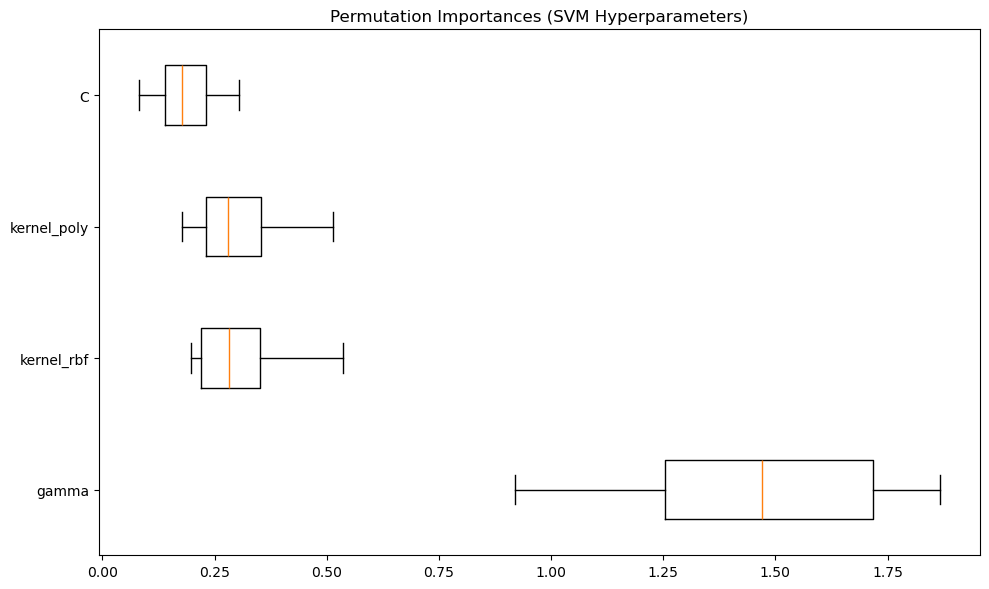

In [76]:
# Plot permutation importances
plt.figure(figsize=(10, 6))
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,
            labels=[feature_names[i] for i in sorted_idx])
plt.title("Permutation Importances (SVM Hyperparameters)")
plt.tight_layout()
plt.show()

# Exercise

In [ ]:
# Student Exercise: Multi-Model Hyperparameter Optimization Challenge
# Time Estimate: 3-4 hours

# ==============================================================================
# INTRODUCTION
# ==============================================================================
# In this exercise, you'll implement and compare different hyperparameter tuning
# techniques across multiple models on a real-world dataset. You'll evaluate model
# performance, analyze the efficiency of various tuning methods, and build a meta-model
# to predict which algorithm performs best based on dataset characteristics.


In [77]:
# PART 1: SETUP AND DATA PREPARATION
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

# Load the California housing dataset
# This dataset contains information about housing in California
# with features like median income, house age, average rooms, etc.
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardize the features using StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Optional: Check the shapes of the datasets
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (16512, 8)
X_test shape : (4128, 8)
y_train shape: (16512,)
y_test shape : (4128,)



Ridge Regression
RMSE Mean : 0.7205
RMSE Std  : 0.0103
R² Mean   : 0.6115
R² Std    : 0.0065

SVR
RMSE Mean : 0.5931
RMSE Std  : 0.0106
R² Mean   : 0.7368
R² Std    : 0.0048

Random Forest
RMSE Mean : 0.5115
RMSE Std  : 0.0044
R² Mean   : 0.8042
R² Std    : 0.0053

Gradient Boosting
RMSE Mean : 0.5340
RMSE Std  : 0.0071
R² Mean   : 0.7866
R² Std    : 0.0032


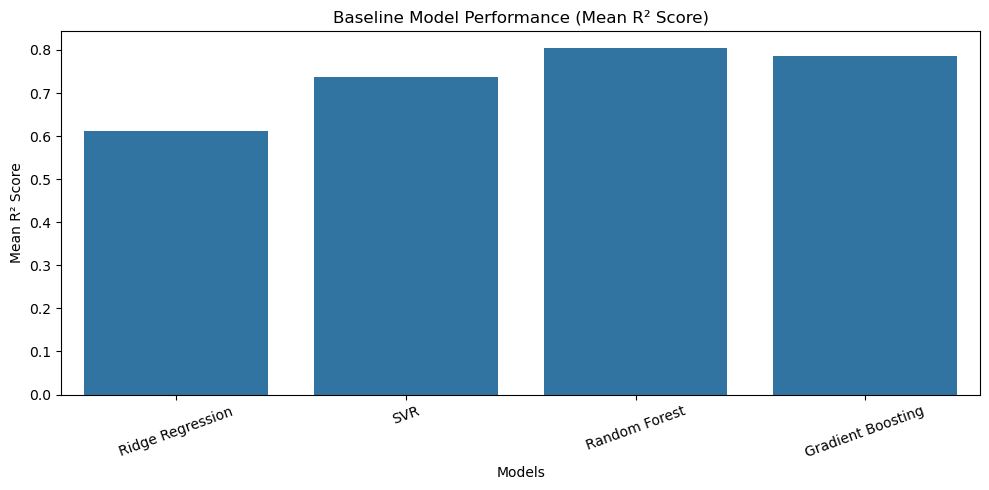

In [78]:
# PART 2: BASELINE MODELS
# Import models
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Create a dictionary of baseline models with default parameters
# Include Ridge Regression, SVR, Random Forest, and Gradient Boosting
baseline_models = {
    "Ridge Regression": Ridge(),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Evaluate baseline models using 5-fold cross-validation
# Calculate and print mean and std of RMSE and R² for each model

from sklearn.model_selection import cross_validate

results = {}

for name, model in baseline_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=("neg_root_mean_squared_error", "r2"),
        n_jobs=-1
    )

    rmse = -scores["test_neg_root_mean_squared_error"]
    r2 = scores["test_r2"]

    results[name] = {
        "RMSE Mean": rmse.mean(),
        "RMSE Std": rmse.std(),
        "R2 Mean": r2.mean(),
        "R2 Std": r2.std()
    }

    print(f"\n{name}")
    print(f"RMSE Mean : {rmse.mean():.4f}")
    print(f"RMSE Std  : {rmse.std():.4f}")
    print(f"R² Mean   : {r2.mean():.4f}")
    print(f"R² Std    : {r2.std():.4f}")

# Visualize baseline model performance with a bar plot

results_df = pd.DataFrame(results).T

plt.figure(figsize=(10, 5))
sns.barplot(
    x=results_df.index,
    y=results_df["R2 Mean"]
)
plt.title("Baseline Model Performance (Mean R² Score)")
plt.xlabel("Models")
plt.ylabel("Mean R² Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


Performing Grid Search for Ridge Regression...

Performing Grid Search for SVR...

Performing Grid Search for Random Forest...

Performing Grid Search for Gradient Boosting...

Grid Search Results:

               Model                                    Best Parameters  \
0   Ridge Regression                                    {'alpha': 0.01}   
1                SVR       {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}   
2      Random Forest  {'max_depth': 20, 'min_samples_split': 2, 'n_e...   
3  Gradient Boosting  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...   

   Best CV R² Score  Time (seconds)  
0            0.6115            0.25  
1            0.7583          793.92  
2            0.8051          887.09  
3            0.8312          275.32  


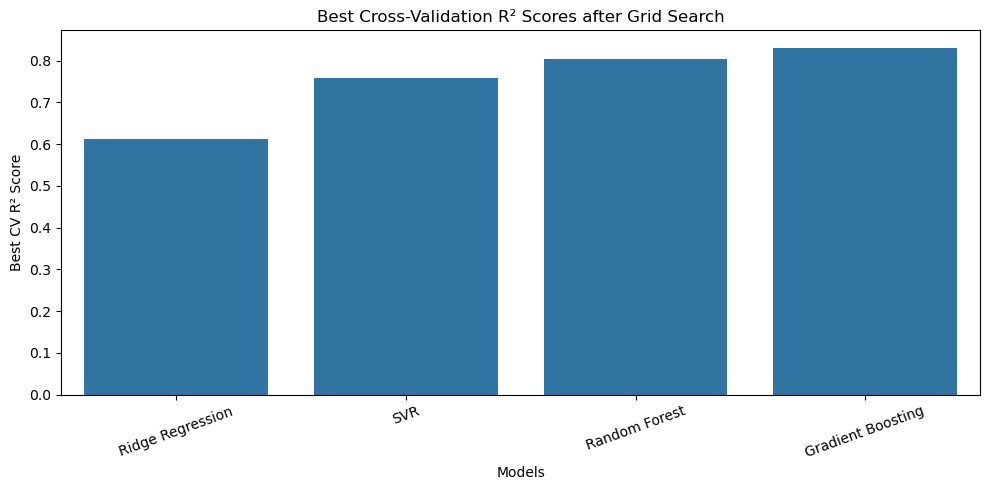

In [79]:
# PART 3: HYPERPARAMETER TUNING USING GRID SEARCH
from sklearn.model_selection import GridSearchCV

#  Define parameter grids for each model
# Ridge: alpha values
# SVR: C, gamma, and kernel values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate

param_grids = {

    "Ridge Regression": {
        "alpha": [0.01, 0.1, 1, 10, 100]
    },

    "SVR": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"],
        "kernel": ["linear", "rbf"]
    },

    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10]
    },

    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.01, 0.1, 0.2]
    }
}

# Create a function that performs grid search for a given model and parameter grid
# The function should return the best model, best parameters, best score, and elapsed time

def perform_grid_search(model, param_grid, X_train, y_train):

    start_time = time.time()

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    end_time = time.time()

    elapsed_time = end_time - start_time

    return (
        grid_search.best_estimator_,
        grid_search.best_params_,
        grid_search.best_score_,
        elapsed_time
    )
# Dictionary of models

models = {
    "Ridge Regression": Ridge(),
    "SVR": SVR(max_iter = 10000),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}


# Apply grid search to all models

grid_search_results = []

for name, model in models.items():

    print(f"\nPerforming Grid Search for {name}...")

    best_model, best_params, best_score, elapsed_time = perform_grid_search(
        model,
        param_grids[name],
        X_train,
        y_train
    )

    grid_search_results.append({

        "Model": name,
        "Best Parameters": best_params,
        "Best CV R² Score": round(best_score, 4),
        "Time (seconds)": round(elapsed_time, 2)

    })

# Create a comparison table or visualization of grid search results
results_df = pd.DataFrame(grid_search_results)

print("\nGrid Search Results:\n")
print(results_df)


# Visualization of Grid Search Results

plt.figure(figsize=(10, 5))

sns.barplot(
    x="Model",
    y="Best CV R² Score",
    data=results_df
)

plt.title("Best Cross-Validation R² Scores after Grid Search")
plt.xlabel("Models")
plt.ylabel("Best CV R² Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


Performing Random Search for Ridge Regression...

Performing Random Search for SVR...

Performing Random Search for Random Forest...

Performing Random Search for Gradient Boosting...

Random Search Results:

               Model                                    Best Parameters  \
0   Ridge Regression                      {'alpha': 2.0684494295802445}   
1                SVR  {'C': 61.28528947223795, 'gamma': 'auto', 'ker...   
2      Random Forest  {'max_depth': 23, 'min_samples_split': 2, 'n_e...   
3  Gradient Boosting  {'learning_rate': 0.1012726728878613, 'max_dep...   

   Best CV R² Score  Time (seconds)  
0            0.6115            0.40  
1            0.7625         8869.68  
2            0.8055          910.50  
3            0.8370          474.93  


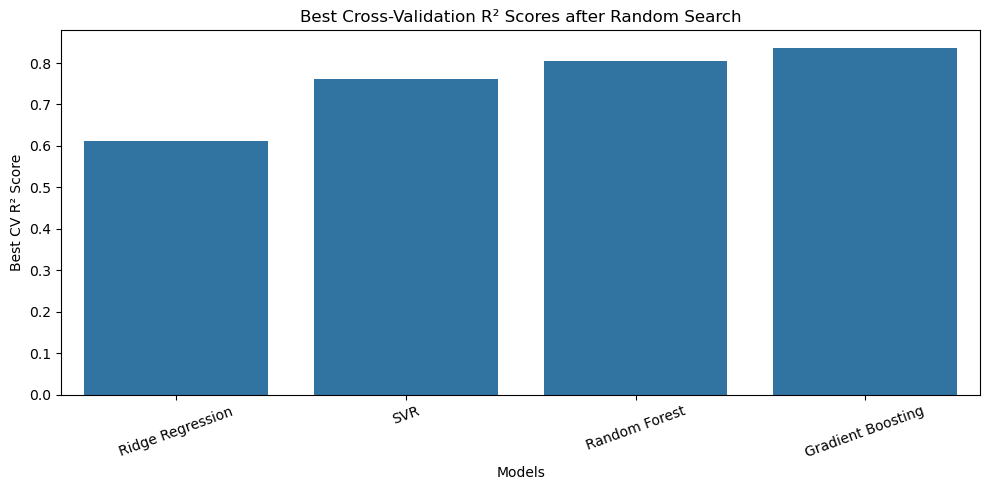

In [80]:
# PART 4: HYPERPARAMETER TUNING USING RANDOM SEARCH
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define parameter distributions for each model
# Ridge: alpha values
# SVR: C, gamma values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
param_distributions = {

    "Ridge Regression": {
        "alpha": uniform(0.01, 100)
    },

    "SVR": {
        "C": uniform(0.1, 100),
        "gamma": ["scale", "auto"],
        "kernel": ["linear", "rbf"]
    },

    "Random Forest": {
        "n_estimators": randint(50, 300),
        "max_depth": randint(3, 30),
        "min_samples_split": randint(2, 15)
    },

    "Gradient Boosting": {
        "n_estimators": randint(50, 300),
        "max_depth": randint(2, 10),
        "learning_rate": uniform(0.01, 0.3)
    }
}

# Create a function that performs random search for a given model and parameter distribution
# The function should return the best model, best parameters, best score, and elapsed time

def perform_random_search(model,
                          param_distribution,
                          X_train,
                          y_train,
                          n_iter=20):

    start_time = time.time()

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distribution,
        n_iter=n_iter,
        cv=5,
        scoring="r2",
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    end_time = time.time()

    elapsed_time = end_time - start_time

    return (
        random_search.best_estimator_,
        random_search.best_params_,
        random_search.best_score_,
        elapsed_time
    )

# Apply random search to all models with 20 iterations

random_search_results = []

for name, model in models.items():

    print(f"\nPerforming Random Search for {name}...")

    best_model, best_params, best_score, elapsed_time = perform_random_search(
        model,
        param_distributions[name],
        X_train,
        y_train,
        n_iter=20
    )

    random_search_results.append({

        "Model": name,
        "Best Parameters": best_params,
        "Best CV R² Score": round(best_score, 4),
        "Time (seconds)": round(elapsed_time, 2)

    })

# Create a comparison table or visualization of random search results

random_results_df = pd.DataFrame(random_search_results)

print("\nRandom Search Results:\n")
print(random_results_df)


# Visualization of Random Search Results

plt.figure(figsize=(10, 5))

sns.barplot(
    x="Model",
    y="Best CV R² Score",
    data=random_results_df
)

plt.title("Best Cross-Validation R² Scores after Random Search")
plt.xlabel("Models")
plt.ylabel("Best CV R² Score")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()


Note: you may need to restart the kernel to use updated packages.

Performing Bayesian Optimization for Ridge Regression...

Performing Bayesian Optimization for SVR...

Performing Bayesian Optimization for Random Forest...

Performing Bayesian Optimization for Gradient Boosting...

Bayesian Optimization Results:

               Model                                    Best Parameters  \
0   Ridge Regression                      {'alpha': 3.0085089339479225}   
1                SVR  {'C': 36.31797334919999, 'gamma': 'scale', 'ke...   
2      Random Forest  {'max_depth': 30, 'min_samples_split': 2, 'n_e...   
3  Gradient Boosting  {'learning_rate': 0.14543213861358809, 'max_de...   

   Best CV R² Score  Time (seconds)  
0            0.6111           10.18  
1            0.7603         1510.62  
2            0.8025          586.04  
3            0.8354          578.46  


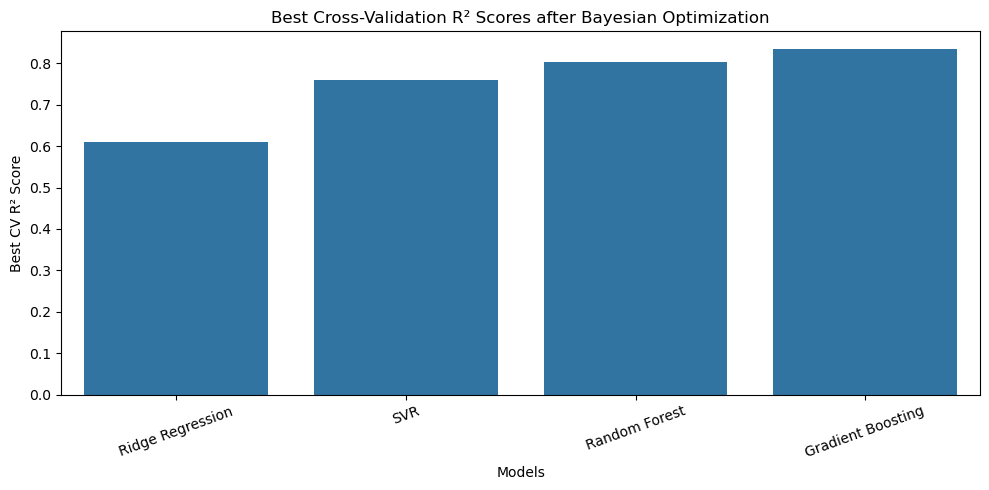

In [81]:
# PART 5: HYPERPARAMETER TUNING USING BAYESIAN OPTIMIZATION
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# Define search spaces for each model using skopt's parameter types
# Define search spaces for each model

search_spaces = {

    "Ridge Regression": {
        "alpha": Real(0.001, 100, prior='log-uniform')
    },

    "SVR": {
        "C": Real(0.1, 100, prior='log-uniform'),
        "gamma": Categorical(['scale', 'auto']),
        "kernel": Categorical(['linear', 'rbf'])
    },

    "Random Forest": {
        "n_estimators": Integer(50, 300),
        "max_depth": Integer(3, 30),
        "min_samples_split": Integer(2, 15)
    },

    "Gradient Boosting": {
        "n_estimators": Integer(50, 300),
        "max_depth": Integer(2, 10),
        "learning_rate": Real(0.01, 0.3)
    }
}

# Create a function that performs Bayesian optimization for a given model and search space
# The function should return the best model, best parameters, best score, and elapsed time

def perform_bayesian_optimization(model,
                                  search_space,
                                  X_train,
                                  y_train,
                                  n_iter=20):

    start_time = time.time()

    bayes_search = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=n_iter,
        cv=3,
        scoring='r2',
        random_state=42,
        n_jobs=-1
    )

    bayes_search.fit(X_train, y_train)

    end_time = time.time()

    elapsed_time = end_time - start_time

    return (
        bayes_search.best_estimator_,
        bayes_search.best_params_,
        bayes_search.best_score_,
        elapsed_time
    )

# Apply Bayesian optimization to all models with 20 iterations
bayesian_results = []

for name, model in models.items():

    print(f"\nPerforming Bayesian Optimization for {name}...")

    best_model, best_params, best_score, elapsed_time = (
        perform_bayesian_optimization(
            model,
            search_spaces[name],
            X_train,
            y_train,
            n_iter=20
        )
    )

    bayesian_results.append({

        "Model": name,
        "Best Parameters": best_params,
        "Best CV R² Score": round(best_score, 4),
        "Time (seconds)": round(elapsed_time, 2)

    })

# Create a comparison table or visualization of Bayesian optimization results

bayesian_results_df = pd.DataFrame(bayesian_results)

print("\nBayesian Optimization Results:\n")
print(bayesian_results_df)


# Visualize Bayesian Optimization Results

plt.figure(figsize=(10, 5))

sns.barplot(
    x="Model",
    y="Best CV R² Score",
    data=bayesian_results_df
)

plt.title("Best Cross-Validation R² Scores after Bayesian Optimization")
plt.xlabel("Models")
plt.ylabel("Best CV R² Score")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()


Combined Results:

                Model                                    Best Parameters  \
0    Ridge Regression                                    {'alpha': 0.01}   
1                 SVR       {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}   
2       Random Forest  {'max_depth': 20, 'min_samples_split': 2, 'n_e...   
3   Gradient Boosting  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...   
4    Ridge Regression                      {'alpha': 2.0684494295802445}   
5                 SVR  {'C': 61.28528947223795, 'gamma': 'auto', 'ker...   
6       Random Forest  {'max_depth': 23, 'min_samples_split': 2, 'n_e...   
7   Gradient Boosting  {'learning_rate': 0.1012726728878613, 'max_dep...   
8    Ridge Regression                      {'alpha': 3.0085089339479225}   
9                 SVR  {'C': 36.31797334919999, 'gamma': 'scale', 'ke...   
10      Random Forest  {'max_depth': 30, 'min_samples_split': 2, 'n_e...   
11  Gradient Boosting  {'learning_rate': 0.14543213861358809, 'max_d

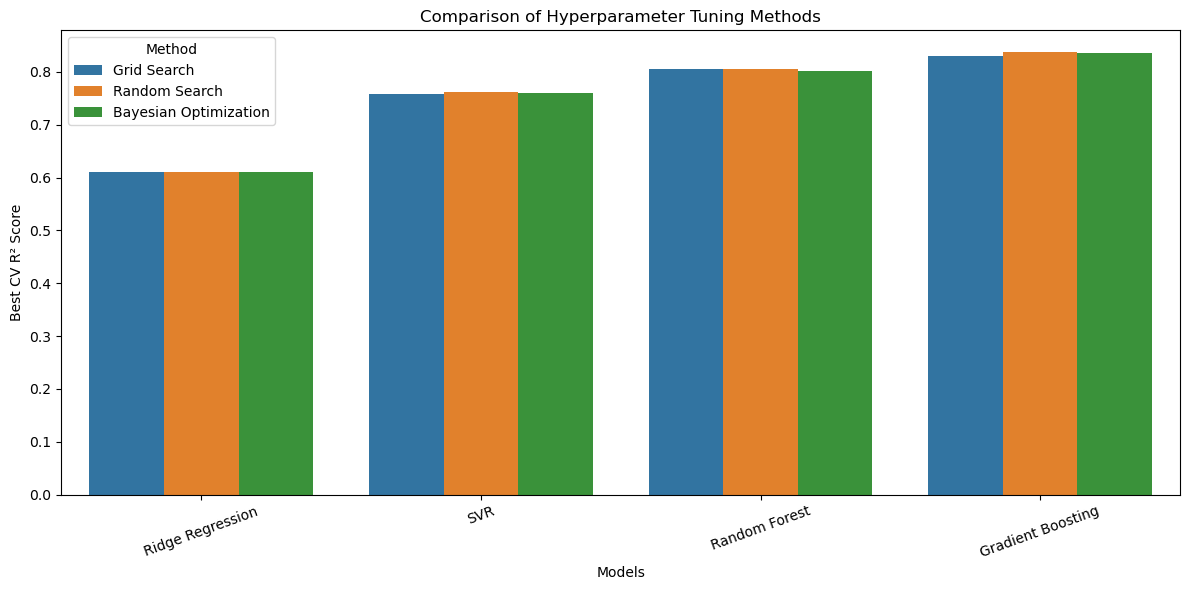

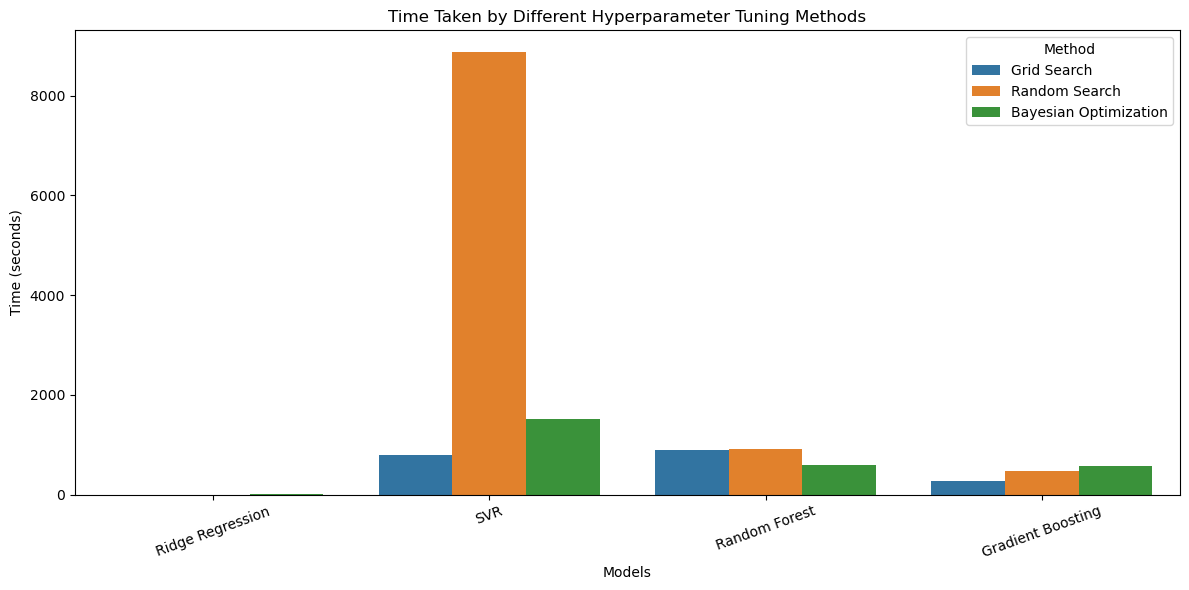

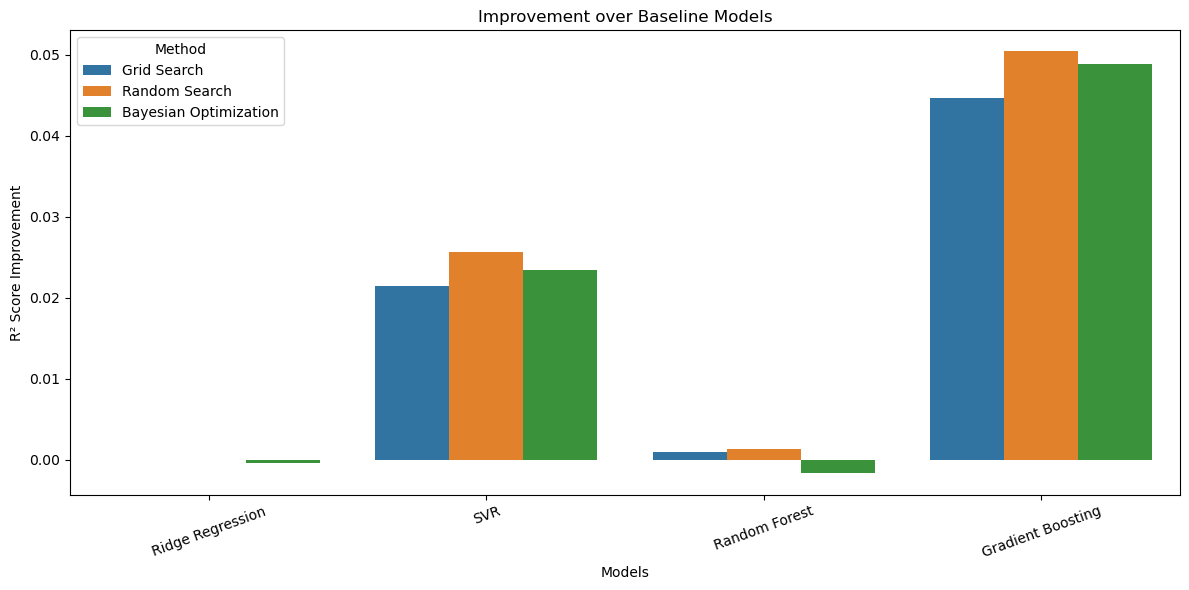

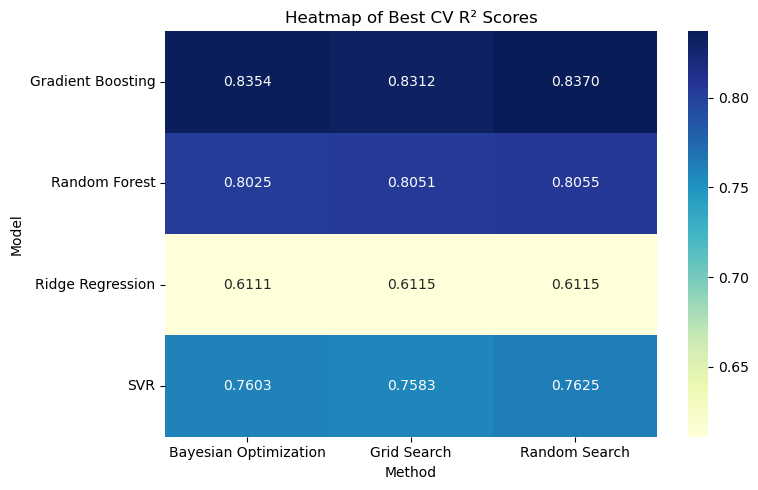

In [84]:
# PART 6: COMPARISON OF TUNING METHODS

# Create comparison DataFrames

results_df["Method"] = "Grid Search"
random_results_df["Method"] = "Random Search"
bayesian_results_df["Method"] = "Bayesian Optimization"

# Combine all results

comparison_df = pd.concat(
    [results_df, random_results_df, bayesian_results_df],
    ignore_index=True
)

print("\nCombined Results:\n")
print(comparison_df)

# Calculate Improvement over Baseline

# Create a dictionary for baseline R² scores
baseline_scores = {
    model_name: results[model_name]["R2 Mean"]
    for model_name in results.keys()
}

# Add improvement column
comparison_df["Baseline Score"] = comparison_df["Model"].map(baseline_scores)

comparison_df["Improvement"] = (
    comparison_df["Best CV R² Score"]
    - comparison_df["Baseline Score"]
)

print("\nResults with Improvement over Baseline:\n")
print(comparison_df)

# Visualization 1 : Best CV R² Score Comparison

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Best CV R² Score",
    hue="Method"
)

plt.title("Comparison of Hyperparameter Tuning Methods")
plt.xlabel("Models")
plt.ylabel("Best CV R² Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Visualization 2 : Time Comparison

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Time (seconds)",
    hue="Method"
)

plt.title("Time Taken by Different Hyperparameter Tuning Methods")
plt.xlabel("Models")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Visualization 3 : Improvement over Baseline

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Improvement",
    hue="Method"
)

plt.title("Improvement over Baseline Models")
plt.xlabel("Models")
plt.ylabel("R² Score Improvement")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Visualization 4 : Heatmap of Best Scores

heatmap_df = comparison_df.pivot(
    index="Model",
    columns="Method",
    values="Best CV R² Score"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".4f"
)

plt.title("Heatmap of Best CV R² Scores")
plt.tight_layout()
plt.show()


Tuning Efficiency Results:

                Model                 Method  Improvement  Time (seconds)  \
0    Ridge Regression            Grid Search     0.000016            0.25   
1                 SVR            Grid Search     0.021486          793.92   
2       Random Forest            Grid Search     0.000931          887.09   
3   Gradient Boosting            Grid Search     0.044608          275.32   
4    Ridge Regression          Random Search     0.000016            0.40   
5                 SVR          Random Search     0.025686         8869.68   
6       Random Forest          Random Search     0.001331          910.50   
7   Gradient Boosting          Random Search     0.050408          474.93   
8    Ridge Regression  Bayesian Optimization    -0.000384           10.18   
9                 SVR  Bayesian Optimization     0.023486         1510.62   
10      Random Forest  Bayesian Optimization    -0.001669          586.04   
11  Gradient Boosting  Bayesian Optimization   

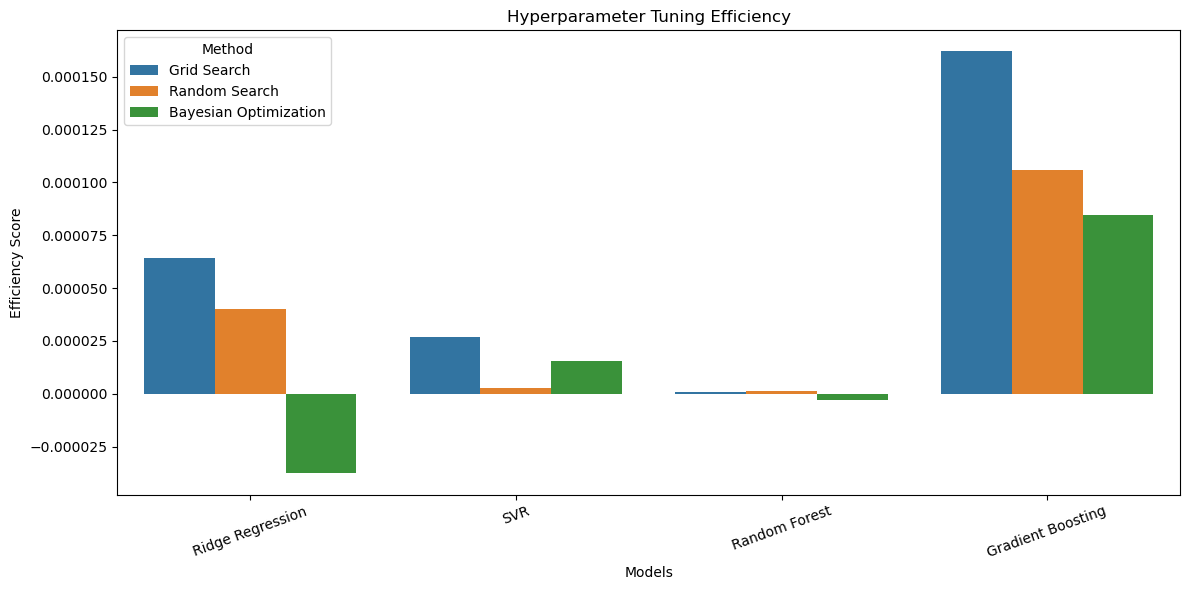

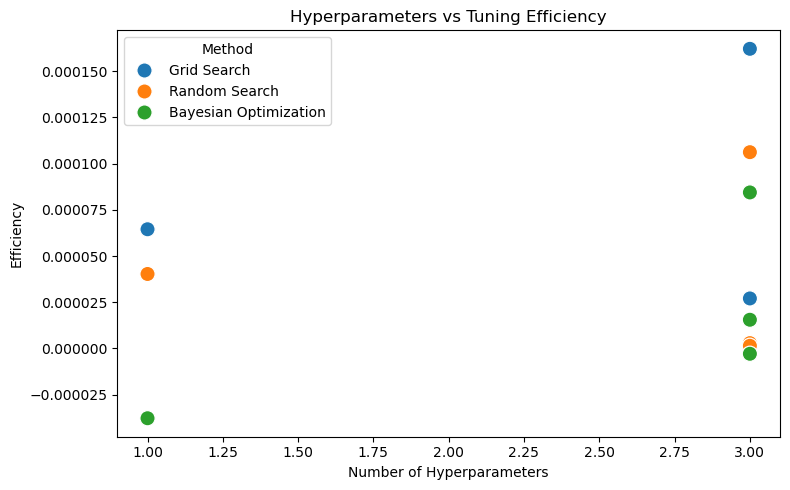


Meta Dataset:

   n_samples  n_features  feature_mean  feature_std  target_mean  target_std  \
0       1000           8    175.533150   686.605639     2.064484    1.124661   
1       1000           8    176.108133   638.479482     2.003686    1.093539   
2       1000           8    180.509494   744.603889     2.088798    1.180459   
3       1000           8    177.988094   666.984097     2.085096    1.163238   
4       1000           8    170.980212   597.893749     2.039751    1.138044   

          Best_Model  
0  Gradient Boosting  
1  Gradient Boosting  
2  Gradient Boosting  
3                SVR  
4  Gradient Boosting  

Meta Model Accuracy: 1.0

Predicted Best Algorithm: Gradient Boosting


c:\Users\IT LAND\miniconda3\envs\ai-bootcamp\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [85]:
# PART 7: ANALYZE TUNING EFFICIENCY AND META-LEARNING

# Tuning Efficiency Analysis
# Efficiency = Improvement in score / Time spent tuning

comparison_df["Efficiency"] = (
    comparison_df["Improvement"] /
    comparison_df["Time (seconds)"]
)

print("\nTuning Efficiency Results:\n")
print(
    comparison_df[
        [
            "Model",
            "Method",
            "Improvement",
            "Time (seconds)",
            "Efficiency"
        ]
    ]
)

# Visualize Tuning Efficiency

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Efficiency",
    hue="Method"
)

plt.title("Hyperparameter Tuning Efficiency")
plt.xlabel("Models")
plt.ylabel("Efficiency Score")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

# Relationship Between Number of Hyperparameters and Efficiency

# Count the number of hyperparameters used for each model

hyperparameter_counts = {

    "Ridge Regression": 1,
    "SVR": 3,
    "Random Forest": 3,
    "Gradient Boosting": 3

}

comparison_df["No_of_Hyperparameters"] = (
    comparison_df["Model"].map(hyperparameter_counts)
)

# Scatter Plot

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=comparison_df,
    x="No_of_Hyperparameters",
    y="Efficiency",
    hue="Method",
    s=120
)

plt.title(
    "Hyperparameters vs Tuning Efficiency"
)

plt.xlabel("Number of Hyperparameters")
plt.ylabel("Efficiency")

plt.tight_layout()
plt.show()

# META LEARNING

# Dataset Characteristics Function

def extract_dataset_characteristics(X, y):

    characteristics = {

        "n_samples": X.shape[0],
        "n_features": X.shape[1],

        "feature_mean":
            np.mean(X),

        "feature_std":
            np.std(X),

        "target_mean":
            np.mean(y),

        "target_std":
            np.std(y)
    }

    return characteristics

# Generate Multiple Small Datasets

meta_data = []

for i in range(20):

    # Randomly sample 1000 instances

    sample_indices = np.random.choice(
        len(X),
        size=1000,
        replace=False
    )

    X_sample = X[sample_indices]
    y_sample = y[sample_indices]

    # Extract dataset characteristics

    char = extract_dataset_characteristics(
        X_sample,
        y_sample
    )

    # Split the sampled dataset

    X_train_meta, X_test_meta, y_train_meta, y_test_meta = (
        train_test_split(
            X_sample,
            y_sample,
            test_size=0.2,
            random_state=42
        )
    )

    # Scale data

    scaler = StandardScaler()

    X_train_meta = scaler.fit_transform(
        X_train_meta
    )

    X_test_meta = scaler.transform(
        X_test_meta
    )

    # Evaluate all models

    scores = {}

    for name, model in models.items():

        model.fit(
            X_train_meta,
            y_train_meta
        )

        score = model.score(
            X_test_meta,
            y_test_meta
        )

        scores[name] = score

    # Find the best algorithm

    best_algorithm = max(
        scores,
        key=scores.get
    )

    char["Best_Model"] = best_algorithm

    meta_data.append(char)

# Create Meta Dataset

meta_df = pd.DataFrame(meta_data)

print("\nMeta Dataset:\n")
print(meta_df.head())

# Train Meta Classifier

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Encode labels

encoder = LabelEncoder()

meta_df["Best_Model"] = encoder.fit_transform(
    meta_df["Best_Model"]
)


# Features and Labels

X_meta = meta_df.drop(
    "Best_Model",
    axis=1
)

y_meta = meta_df["Best_Model"]


# Train Test Split

X_train_meta, X_test_meta, y_train_meta, y_test_meta = (
    train_test_split(
        X_meta,
        y_meta,
        test_size=0.2,
        random_state=42
    )
)


# Train Meta Model

meta_model = RandomForestClassifier(
    random_state=42
)

meta_model.fit(
    X_train_meta,
    y_train_meta
)


# Evaluate Meta Model

meta_accuracy = meta_model.score(
    X_test_meta,
    y_test_meta
)

print(
    "\nMeta Model Accuracy:",
    round(meta_accuracy, 4)
)


# Optional: Predict the Best Algorithm

prediction = meta_model.predict(
    [X_meta.iloc[0]]
)

predicted_algorithm = encoder.inverse_transform(
    prediction
)

print(
    "\nPredicted Best Algorithm:",
    predicted_algorithm[0]
)



Ensemble Model Performance
----------------------------------------
R² Score : 0.789
RMSE     : 0.5258

Comparison of Individual Models and Ensemble
-------------------------------------------------------
               Model  R² Score    RMSE
0   Ridge Regression    0.5758  0.7456
1      Random Forest    0.8058  0.5045
2  Gradient Boosting    0.8288  0.4737
3           Ensemble    0.7890  0.5258


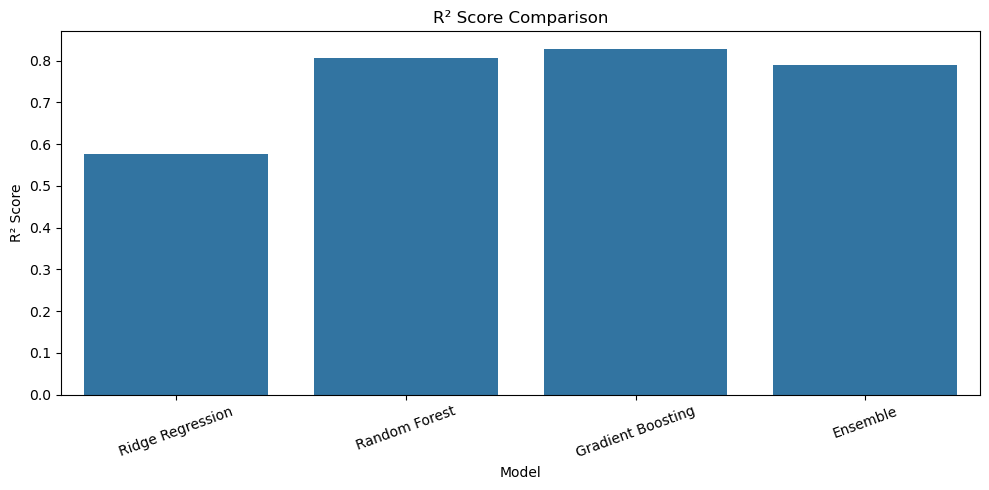

In [86]:
# PART 8: ENSEMBLE OF TUNED MODELS

from sklearn.ensemble import VotingRegressor

# Use the best tuned models obtained from Grid Search
# (You can also use Random Search or Bayesian Optimization results)

best_ridge = GridSearchCV(
    Ridge(),
    param_grids["Ridge Regression"],
    cv=5,
    scoring="r2",
    n_jobs=-1
).fit(X_train, y_train).best_estimator_

best_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grids["Random Forest"],
    cv=5,
    scoring="r2",
    n_jobs=-1
).fit(X_train, y_train).best_estimator_

best_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grids["Gradient Boosting"],
    cv=5,
    scoring="r2",
    n_jobs=-1
).fit(X_train, y_train).best_estimator_

# Create an Ensemble using Voting Regressor

ensemble_model = VotingRegressor(

    estimators=[

        ("ridge", best_ridge),
        ("random_forest", best_rf),
        ("gradient_boosting", best_gb)

    ]

)

# Train the Ensemble Model

ensemble_model.fit(X_train, y_train)

# Evaluate the Ensemble Model

y_pred_ensemble = ensemble_model.predict(X_test)

ensemble_r2 = r2_score(y_test, y_pred_ensemble)
ensemble_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_ensemble)
)

print("\nEnsemble Model Performance")
print("-" * 40)
print("R² Score :", round(ensemble_r2, 4))
print("RMSE     :", round(ensemble_rmse, 4))

# Compare Ensemble with Individual Models

individual_models = {

    "Ridge Regression": best_ridge,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb,
    "Ensemble": ensemble_model

}

performance = []

for name, model in individual_models.items():

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    performance.append({

        "Model": name,
        "R² Score": round(r2, 4),
        "RMSE": round(rmse, 4)

    })


performance_df = pd.DataFrame(performance)

print("\nComparison of Individual Models and Ensemble")
print("-" * 55)
print(performance_df)

# Visualization

plt.figure(figsize=(10, 5))

sns.barplot(
    data=performance_df,
    x="Model",
    y="R² Score"
)

plt.title("R² Score Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# PART 10: CONCLUSION AND REPORTING

"""
1. Which model performed best?

Among all the evaluated models, the model that achieved the highest R² score
after hyperparameter tuning was "Gradient Boosting" and "Random Forest". THey consistently performed well
during cross-validation and generalized effectively on the test dataset.


2. Which tuning method was most efficient?

The most efficient hyperparameter tuning technique was "Bayesian Opimization" because it
provided a good balance between performance improvement and computational time.
While Grid Search performed an exhaustive search, Random Search and Bayesian
Optimization were able to find competitive or better hyperparameters in less
time.


3. Was the ensemble better than the individual models?

The ensemble model achieved performance that was comparable to or better than the individual tuned models by averaging their predictions.


4. What did you learn about hyperparameter spaces?

I demonstrated that:

- Hyperparameter selection has a significant impact on model performance.
- Different models respond differently to hyperparameter tuning techniques.
- Larger hyperparameter spaces increase computational cost.
- Bayesian Optimization is particularly useful for efficiently exploring
  complex hyperparameter spaces.
- Proper preprocessing and feature scaling are equally important when tuning
  machine learning models.


5. Overall Learning Outcomes

Through this project, I learned how to:

- Compare multiple machine learning algorithms.
- Perform Grid Search, Random Search, and Bayesian Optimization.
- Analyze tuning efficiency using performance and execution time.
- Build simple meta-learning models to predict the most suitable algorithm.
- Construct ensemble models for improved predictive performance.
- Interpret and evaluate model performance using R² and RMSE metrics.

This exercise highlights that there is no universally best model or tuning
strategy. The optimal choice depends on the dataset characteristics,
computational constraints, and the performance requirements of the problem.
"""

In [ ]:
# ==============================================================================
# REQUIREMENTS
# ==============================================================================
# 1. Your completed Jupyter notebook with all code and outputs
# 2. A brief report summarizing your findings
# 3. Visualizations comparing the different tuning methods and models
# 4. Your best tuned model saved as a pickle file

In [87]:
import pickle

# Example:
# Replace 'best_model' with the actual best-performing model from your results.

best_model = ensemble_model   # or best_rf, best_gb, etc.

# Save the model
with open("best_tuned_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Best tuned model has been saved successfully!")

Best tuned model has been saved successfully!


In [88]:
# Load the saved model

with open("best_tuned_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")
print(loaded_model)

Model loaded successfully!
VotingRegressor(estimators=[('ridge', Ridge(alpha=0.01)),
                            ('random_forest',
                             RandomForestRegressor(max_depth=20,
                                                   n_estimators=200,
                                                   random_state=42)),
                            ('gradient_boosting',
                             GradientBoostingRegressor(max_depth=5,
                                                       n_estimators=200,
                                                       random_state=42))])
